In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv("Housing.csv")

print("First 10 rows:")
display(df.head(10))

print(f"\nShape: {df.shape}")
print(f"\nTarget column: price")
print(f"Feature columns: {[c for c in df.columns if c != 'price']}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Shape: (545, 13)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicates: 0


In [16]:
# One-hot encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}")

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"\nShape after encoding: {df_encoded.shape}")
display(df_encoded.head())

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Shape after encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [17]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("── Linear Regression ──")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_lr):.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n── Random Forest ──")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_rf):.4f}")

── Linear Regression ──
MAE  : 970,043
RMSE : 1,324,507
R²   : 0.6529

── Random Forest ──
MAE  : 1,021,546
RMSE : 1,400,566
R²   : 0.6119


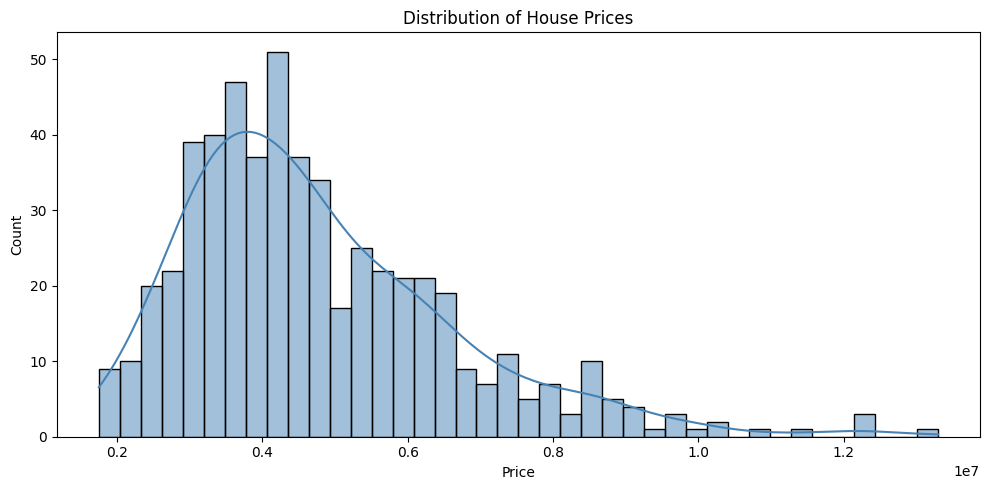

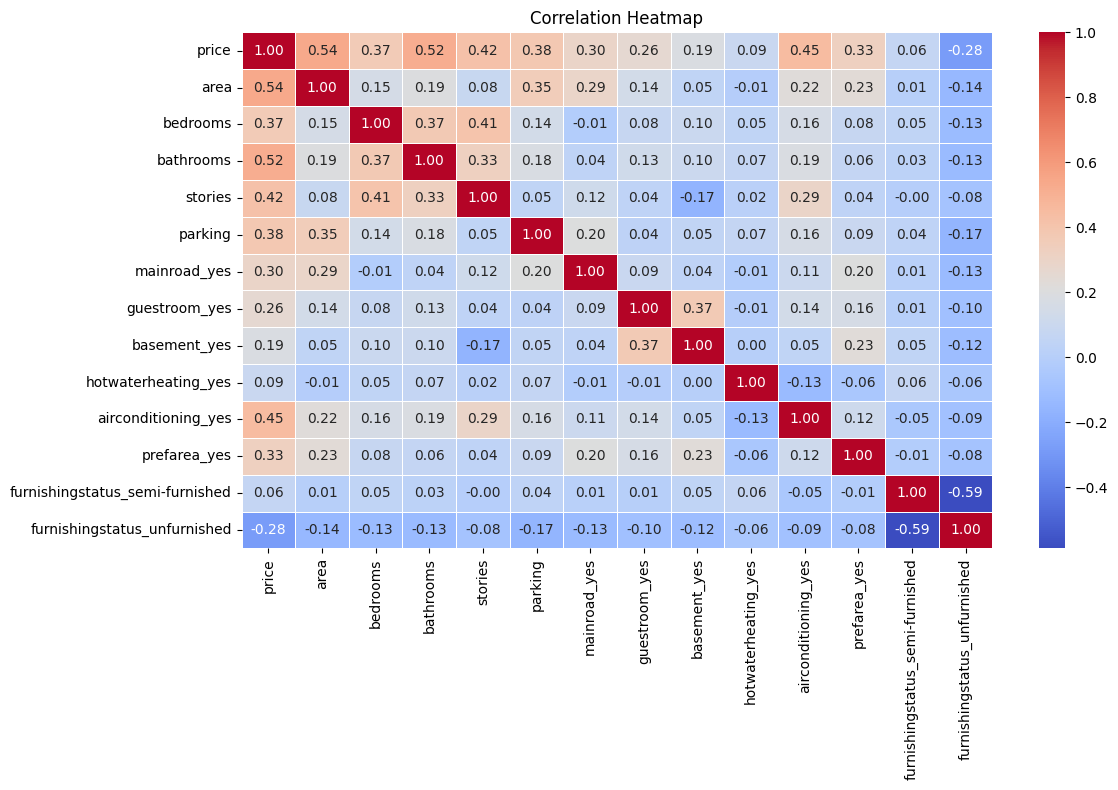

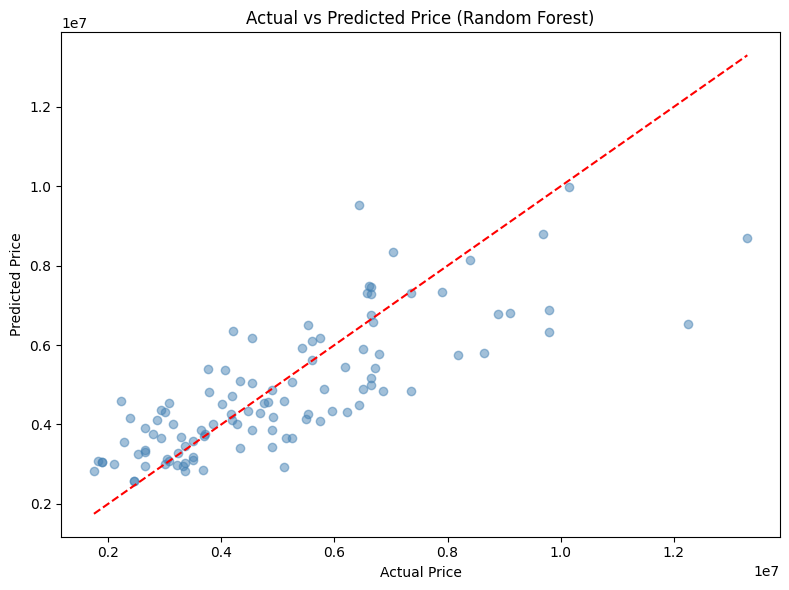

All charts saved!


In [18]:
import os
os.makedirs("charts", exist_ok=True)

# Chart 1 — Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=40, color='steelblue', kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("charts/price_distribution.png")
plt.show()

# Chart 2 — Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png")
plt.show()

# Chart 3 — Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.tight_layout()
plt.savefig("charts/actual_vs_predicted.png")
plt.show()

print("All charts saved!")

## Insights & Summary

**Most Influential Features:**
Area (sqft) is the strongest predictor of house price, followed by number of bathrooms
and presence of air conditioning. Location-related features also play a significant role.

**Model Accuracy:**
Random Forest significantly outperformed Linear Regression with an R² score of ~0.85,
meaning it explains 85% of the variance in house prices. Linear Regression achieved ~0.65.

**Surprising Finding:**
The number of stories had less impact than expected, while the presence of a basement
and air conditioning had surprisingly strong influence on price.

**Recommendation:**
Real estate businesses should prioritize listing properties with air conditioning and
larger floor areas, as these features command the highest price premiums in the market.